# Astro Iterative Run Analysis Notebook

This notebook analyses the **Astro/WIESP iterative target-injection run** using the available `runs/iter_astro/summary.csv`.

It keeps the same general report structure as the CoNLL notebook, but the analysis is adapted to the current Astro situation: **only one seed is available** and only the summary CSV has been recovered from the HPC run.


This version displays the Astro target-injection x-axis as `n_target_examples × 30`, so it is roughly comparable to the CoNLL sentence-scale plots.

## Important note about missing seeds and recovered files

The intended Astro experiment was meant to match the CoNLL setup with **3 seeds × 20 iterations × 3 evaluation sets**.

However, the HPC jobs timed out before all seeds and per-iteration files could be fully recovered. The current Astro run folder contains only:

```text
runs/
└── iter_astro/
    └── summary.csv
```

Because of this, the notebook uses the available single-seed summary data only. We can still analyse learning curves, final performance, transfer behaviour, per-entity F1, and resource trends. But we cannot yet analyse seed variability, confidence bands, confusion matrices, or training-log dynamics. Those sections are marked clearly and should be completed later once the missing HPC outputs are available.


## 1. Paths and data loading

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

RUN_DIR = Path("runs/iter_astro")

# Fallback only for testing this notebook outside the repo
if not RUN_DIR.exists() and Path("/mnt/data/summary.csv").exists():
    RUN_DIR = Path("/mnt/data")

SUMMARY_PATH = RUN_DIR / "summary.csv"

print("RUN_DIR:", RUN_DIR.resolve())
print("SUMMARY_PATH exists:", SUMMARY_PATH.exists())

summary = pd.read_csv(SUMMARY_PATH)
summary.head()

RUN_DIR: C:\Users\rudra\OneDrive - ITU\Cross_domain_NER_Project_2026\runs\iter_astro
SUMMARY_PATH exists: True


,exp_name,seed,iteration,n_blocks,n_target_examples,n_source_examples,train_set_size,target_fraction,eval_set,entity_f1_micro,entity_f1_macro,entity_f1_weighted,entity_precision,entity_recall,token_f1,token_acc,eval_loss,delta_f1_vs_iter0,f1_Archive,f1_CelestialObject,f1_CelestialObjectRegion,f1_CelestialRegion,f1_Citation,f1_Collaboration,f1_ComputingFacility,f1_Database,f1_Dataset,f1_EntityOfFutureInterest,f1_Event,f1_Fellowship,f1_Formula,f1_Grant,f1_Identifier,f1_Instrument,f1_LOC,f1_Mission,f1_Model,f1_ORG,f1_ObservationalTechniques,f1_Observatory,f1_PER,f1_Proposal,f1_Software,f1_Survey,f1_Tag,f1_Telescope,f1_TextGarbage,f1_URL,f1_Wavelength,support_Archive,support_CelestialObject,support_CelestialObjectRegion,support_CelestialRegion,support_Citation,support_Collaboration,support_ComputingFacility,support_Database,support_Dataset,support_EntityOfFutureInterest,support_Event,support_Fellowship,support_Formula,support_Grant,support_Identifier,support_Instrument,support_LOC,support_Mission,support_Model,support_ORG,support_ObservationalTechniques,support_Observatory,support_PER,support_Proposal,support_Software,support_Survey,support_Tag,support_Telescope,support_TextGarbage,support_URL,support_Wavelength,best_epoch,train_time_sec,peak_gpu_mem_mb
0,iter_astro,42,0,0,0,12543,12543,0.000000,ewt_dev,0.804890,0.794181,0.806173,0.762743,0.851967,0.887666,0.984373,0.070893,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.803898,NaN,NaN,0.701403,NaN,NaN,0.877241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399,NaN,NaN,224,NaN,NaN,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,996.142146,5586
1,iter_astro,42,0,0,0,12543,12543,0.000000,conll_test,0.702273,0.684781,0.683091,0.708119,0.696522,0.801064,0.952256,0.303857,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.693723,NaN,NaN,0.484434,NaN,NaN,0.876185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668,NaN,NaN,1661,NaN,NaN,1617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,996.142146,5586
2,iter_astro,42,0,0,0,12543,12543,0.000000,astro_test,0.309910,0.046602,0.199101,0.490274,0.226561,0.087269,0.841996,1.996035,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.295113,0.0,0.0,0.575379,0.0,0.0,0.574176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,324.0,2419.0,484.0,148.0,6042.0,360.0,588.0,297.0,339.0,304.0,55.0,594.0,2401.0,5038.0,146.0,813.0,2097,170.0,2366.0,10436,61.0,1141.0,5940,159.0,1112.0,915.0,74.0,1881.0,192.0,350.0,3151.0,7,996.142146,5586
3,iter_astro,42,1,5,5,12543,12548,0.000398,ewt_dev,0.797933,0.783661,0.799113,0.796698,0.799172,0.872360,0.983737,0.098140,-0.006957,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.804627,NaN,NaN,0.668094,NaN,NaN,0.878261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399,NaN,NaN,224,NaN,NaN,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,1527.636734,11767
4,iter_astro,42,1,5,5,12543,12548,0.000398,conll_test,0.703047,0.684713,0.682716,0.726391,0.681156,0.796403,0.952062,0.414492,0.000774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.692189,NaN,NaN,0.451613,NaN,NaN,0.910336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668,NaN,NaN,1661,NaN,NaN,1617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,1527.636734,11767


## Astro target-axis conversion

In the Astro experiment, one injected Astro unit represents approximately **30 CoNLL-style sentence units**.

Before plotting, we create a new display column:

```python
n_target_examples_display = n_target_examples * 30
```

All graphs still use the original results, but the x-axis is shown on this sentence-equivalent scale so it is easier to compare with the CoNLL analysis.


In [ ]:
# Convert Astro target units to an approximate CoNLL-comparable sentence scale.
# This only changes the x-axis display used in plots; it does not change the actual metrics.
ASTRO_UNIT_MULTIPLIER = 30

summary["n_target_examples_display"] = summary["n_target_examples"] * ASTRO_UNIT_MULTIPLIER

print("Raw Astro target units:")
print(summary.groupby("iteration")["n_target_examples"].first().to_list())

print("\nDisplayed x-axis units after ×30 conversion:")
print(summary.groupby("iteration")["n_target_examples_display"].first().to_list())


In [ ]:
print("Summary shape:", summary.shape)
print("Seeds:", sorted(summary["seed"].unique()))
print("Iterations:", summary["iteration"].min(), "to", summary["iteration"].max())
print("Eval sets:", sorted(summary["eval_set"].unique()))
print("Expected rows from available data =", summary["seed"].nunique() * summary["iteration"].nunique() * summary["eval_set"].nunique())
print("Target schedule:", summary.groupby("iteration")["n_target_examples"].first().to_list())

Summary shape: (60, 83)
Seeds: [42]
Iterations: 0 to 19
Eval sets: ['astro_test', 'conll_test', 'ewt_dev']
Expected rows from available data = 60
Target schedule: [0, 5, 7, 10, 15, 20, 25, 35, 50, 70, 95, 130, 180, 250, 350, 490, 675, 935, 1300, 1800]


## 2. Visual style template

In [ ]:
BG = "#f6f1eb"          # warm beige/off-white
TEXT = "#2f241f"        # dark brown
EDGE = "#3d3128"        # dark brown-gray
GRID = "#8b6f5a"        # muted brown

DOMAIN_COLORS = {
    "ewt_dev": "#EFA6C1",      # muted pink
    "conll_test": "#8FD3B6",   # pastel mint green
    "astro_test": "#F4B183",   # soft peach / WIESP
}

DOMAIN_LABELS = {
    "ewt_dev": "EWT dev",
    "conll_test": "CoNLL test",
    "astro_test": "WIESP test",
}

METRIC_LABELS = {
    "entity_f1_micro": "Entity micro F1",
    "entity_f1_macro": "Entity macro F1",
    "entity_f1_weighted": "Entity weighted F1",
    "entity_precision": "Entity precision",
    "entity_recall": "Entity recall",
    "token_acc": "Token accuracy",
    "token_f1": "Token F1",
    "eval_loss": "Evaluation loss",
    "delta_f1_vs_iter0": "Δ micro F1 vs iter 0",
}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": EDGE,
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "text.color": TEXT,
    "font.size": 12,
    "axes.titleweight": "bold",
})

def finish_plot(title, xlabel=None, ylabel=None, legend=True, rotate_x=False):
    ax = plt.gca()
    ax.set_title(title, fontsize=20, fontweight="bold", color=TEXT, pad=18)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=13, color=TEXT, labelpad=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=13, color=TEXT, labelpad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(EDGE)
    ax.spines["bottom"].set_color(EDGE)
    ax.grid(axis="y", linestyle="--", alpha=0.20, color=GRID)

    if rotate_x:
        plt.xticks(rotation=25, ha="right")

    if legend:
        leg = ax.legend(frameon=True)
        leg.get_frame().set_facecolor(BG)
        leg.get_frame().set_edgecolor(EDGE)

    plt.tight_layout()

def add_bar_labels(ax, bars, fmt="{:.3f}", y_offset=0.01):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + y_offset,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=10,
            color=TEXT
        )



def target_x(values):
    """
    Transform target-example counts for plotting.
    Uses log10(n + 1), so iteration 0 remains visible at the far-left origin.
    """
    return np.log10(np.asarray(values, dtype=float) + 1.0)

def apply_target_xaxis(ax=None):
    """
    Apply readable original-count tick labels to transformed Astro target-injection plots.
    """
    if ax is None:
        ax = plt.gca()

    if "summary" in globals() and "n_target_examples" in summary.columns:
        schedule = summary.groupby("iteration")["n_target_examples_display"].first().to_list()
    else:
        schedule = [0, 150, 600, 2100, 7500, 20250, 54000]

    tick_candidates = [0, 150, 600, 2100, 7500, 20250, 54000]
    ticks = [t for t in tick_candidates if t in schedule]

    ax.set_xticks(target_x(ticks))
    ax.set_xticklabels([str(t) for t in ticks], rotation=0)
    ax.set_xlim(target_x([0])[0] - 0.03, target_x([max(schedule)])[0] + 0.03)
    return ax

## 3. Single-seed analysis setup

The CoNLL notebook averaged three seeds. Here, only one Astro seed is available, so this setup keeps the same table structure but does **not** represent a true multi-seed average.


In [ ]:
metric_cols = [
    "entity_f1_micro", "entity_f1_macro", "entity_f1_weighted",
    "entity_precision", "entity_recall",
    "token_acc", "token_f1", "eval_loss", "delta_f1_vs_iter0",
    "best_epoch", "train_time_sec", "peak_gpu_mem_mb",
]

f1_type_cols = [c for c in summary.columns if c.startswith("f1_")]
support_cols = [c for c in summary.columns if c.startswith("support_")]

available_cols = [c for c in metric_cols + f1_type_cols + support_cols if c in summary.columns]

analysis_df = (
    summary
    .groupby(["iteration", "n_target_examples", "target_fraction", "eval_set"], as_index=False)
    [available_cols]
    .mean()
)

analysis_df["n_target_examples_display"] = analysis_df["n_target_examples"] * ASTRO_UNIT_MULTIPLIER

astro_df = analysis_df[analysis_df["eval_set"] == "astro_test"].copy()
conll_df = analysis_df[analysis_df["eval_set"] == "conll_test"].copy()
ewt_df = analysis_df[analysis_df["eval_set"] == "ewt_dev"].copy()

final_iter = int(analysis_df["iteration"].max())
final_df = analysis_df[analysis_df["iteration"] == final_iter].copy()

analysis_df.head()

,iteration,n_target_examples,target_fraction,eval_set,entity_f1_micro,entity_f1_macro,entity_f1_weighted,entity_precision,entity_recall,token_acc,token_f1,eval_loss,delta_f1_vs_iter0,best_epoch,train_time_sec,peak_gpu_mem_mb,f1_Archive,f1_CelestialObject,f1_CelestialObjectRegion,f1_CelestialRegion,f1_Citation,f1_Collaboration,f1_ComputingFacility,f1_Database,f1_Dataset,f1_EntityOfFutureInterest,f1_Event,f1_Fellowship,f1_Formula,f1_Grant,f1_Identifier,f1_Instrument,f1_LOC,f1_Mission,f1_Model,f1_ORG,f1_ObservationalTechniques,f1_Observatory,f1_PER,f1_Proposal,f1_Software,f1_Survey,f1_Tag,f1_Telescope,f1_TextGarbage,f1_URL,f1_Wavelength,support_Archive,support_CelestialObject,support_CelestialObjectRegion,support_CelestialRegion,support_Citation,support_Collaboration,support_ComputingFacility,support_Database,support_Dataset,support_EntityOfFutureInterest,support_Event,support_Fellowship,support_Formula,support_Grant,support_Identifier,support_Instrument,support_LOC,support_Mission,support_Model,support_ORG,support_ObservationalTechniques,support_Observatory,support_PER,support_Proposal,support_Software,support_Survey,support_Tag,support_Telescope,support_TextGarbage,support_URL,support_Wavelength
0,0,0,0.000000,astro_test,0.309910,0.046602,0.199101,0.490274,0.226561,0.841996,0.087269,1.996035,0.000000,7.0,996.142146,5586.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.295113,0.0,0.000000,0.575379,0.0,0.0,0.574176,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,324.0,2419.0,484.0,148.0,6042.0,360.0,588.0,297.0,339.0,304.0,55.0,594.0,2401.0,5038.0,146.0,813.0,2097.0,170.0,2366.0,10436.0,61.0,1141.0,5940.0,159.0,1112.0,915.0,74.0,1881.0,192.0,350.0,3151.0
1,0,0,0.000000,conll_test,0.702273,0.684781,0.683091,0.708119,0.696522,0.952256,0.801064,0.303857,0.000000,7.0,996.142146,5586.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.693723,NaN,NaN,0.484434,NaN,NaN,0.876185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668.0,NaN,NaN,1661.0,NaN,NaN,1617.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,0,0.000000,ewt_dev,0.804890,0.794181,0.806173,0.762743,0.851967,0.984373,0.887666,0.070893,0.000000,7.0,996.142146,5586.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.803898,NaN,NaN,0.701403,NaN,NaN,0.877241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399.0,NaN,NaN,224.0,NaN,NaN,343.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,5,0.000398,astro_test,0.351580,0.066003,0.259360,0.427803,0.298411,0.872990,0.124738,1.361278,0.041670,14.0,1527.636734,11767.0,0.0,0.0,0.0,0.0,0.475176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.043777,0.0,0.0,0.292534,0.0,0.022316,0.479581,0.0,0.0,0.717776,0.0,0.0,0.0,0.0,0.001886,0.0,0.0,0.013052,324.0,2419.0,484.0,148.0,6042.0,360.0,588.0,297.0,339.0,304.0,55.0,594.0,2401.0,5038.0,146.0,813.0,2097.0,170.0,2366.0,10436.0,61.0,1141.0,5940.0,159.0,1112.0,915.0,74.0,1881.0,192.0,350.0,3151.0
4,1,5,0.000398,conll_test,0.703047,0.684713,0.682716,0.726391,0.681156,0.952062,0.796403,0.414492,0.000774,14.0,1527.636734,11767.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.692189,NaN,NaN,0.451613,NaN,NaN,0.910336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668.0,NaN,NaN,1661.0,NaN,NaN,1617.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Entity F1 across iterations

Target-injection plots use a transformed x-axis: `log10(n + 1)`. The tick labels still show the original number of Astro examples.

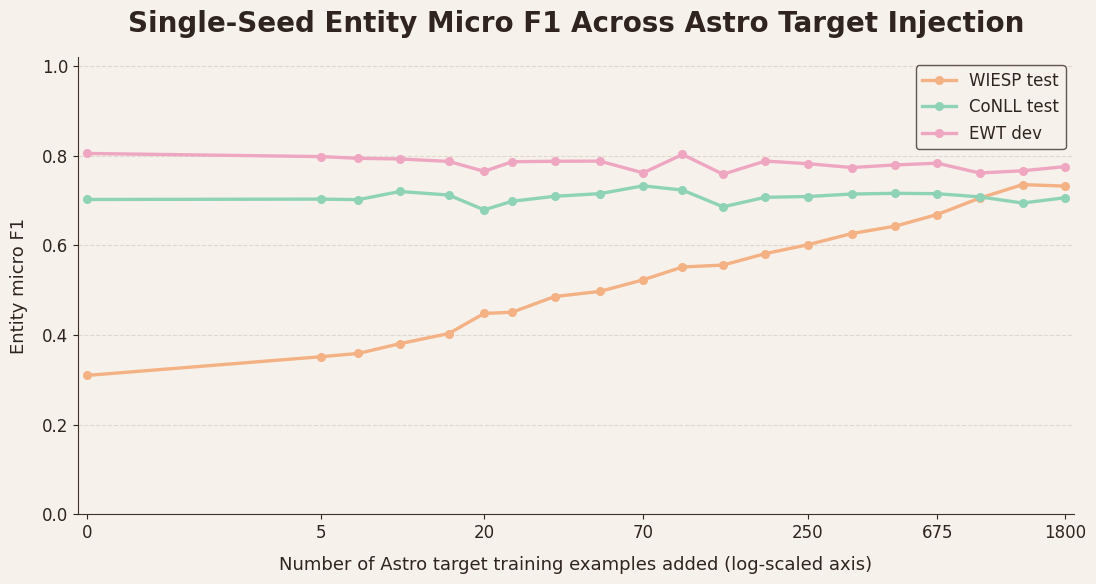

In [ ]:
plt.figure(figsize=(11, 6))

for eval_set, sub in analysis_df.groupby("eval_set"):
    sub = sub.sort_values("n_target_examples")
    plt.plot(
        target_x(sub["n_target_examples_display"]),
        sub["entity_f1_micro"],
        marker="o",
        linewidth=2.4,
        markersize=5.5,
        color=DOMAIN_COLORS.get(eval_set, "gray"),
        label=DOMAIN_LABELS.get(eval_set, eval_set)
    )

finish_plot(
    "Single-Seed Entity Micro F1 Across Astro Target Injection",
    xlabel="Astro target training examples added (×30 sentence-equivalent, log-scaled axis)",
    ylabel="Entity micro F1"
)
plt.ylim(0, 1.02)
apply_target_xaxis()
plt.show()

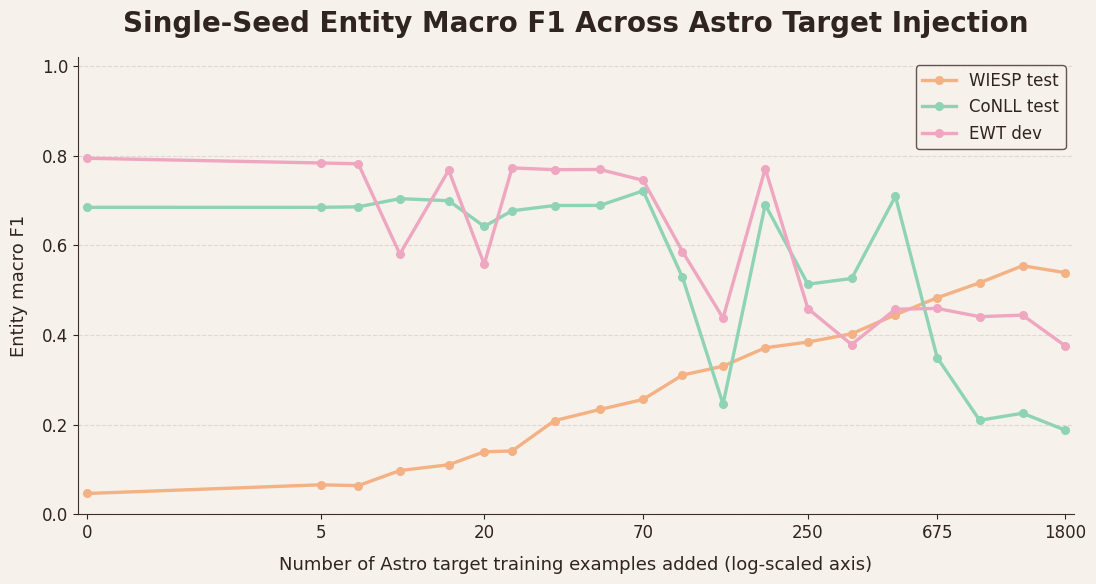

In [ ]:
plt.figure(figsize=(11, 6))

for eval_set, sub in analysis_df.groupby("eval_set"):
    sub = sub.sort_values("n_target_examples")
    plt.plot(
        target_x(sub["n_target_examples_display"]),
        sub["entity_f1_macro"],
        marker="o",
        linewidth=2.4,
        markersize=5.5,
        color=DOMAIN_COLORS.get(eval_set, "gray"),
        label=DOMAIN_LABELS.get(eval_set, eval_set)
    )

finish_plot(
    "Single-Seed Entity Macro F1 Across Astro Target Injection",
    xlabel="Astro target training examples added (×30 sentence-equivalent, log-scaled axis)",
    ylabel="Entity macro F1"
)
plt.ylim(0, 1.02)
apply_target_xaxis()
plt.show()

## 5. WIESP precision, recall, micro F1, macro F1, and token accuracy

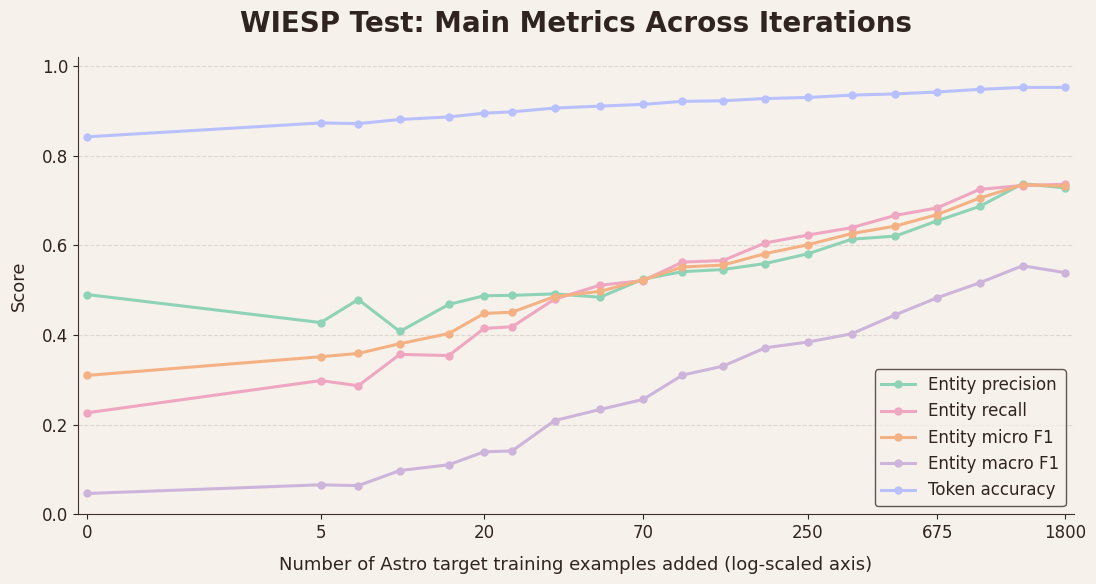

In [ ]:
target_metrics = ["entity_precision", "entity_recall", "entity_f1_micro", "entity_f1_macro", "token_acc"]
target_colors = ["#8FD3B6", "#EFA6C1", "#F4B183", "#CDB4DB", "#B8C0FF"]

plt.figure(figsize=(11, 6))

for col, color in zip(target_metrics, target_colors):
    plt.plot(
        target_x(astro_df["n_target_examples_display"]),
        astro_df[col],
        marker="o",
        linewidth=2.2,
        markersize=5,
        color=color,
        label=METRIC_LABELS.get(col, col)
    )

finish_plot(
    "WIESP Test: Main Metrics Across Iterations",
    xlabel="Astro target training examples added (×30 sentence-equivalent, log-scaled axis)",
    ylabel="Score"
)
plt.ylim(0, 1.02)
apply_target_xaxis()
plt.show()

## 6. Seed variability around WIESP micro F1

This section is intentionally different from the CoNLL notebook.

The CoNLL analysis had three seeds, so it could show mean performance with ±1 standard deviation. The Astro summary currently has only one seed, so a seed-variability curve would be misleading. This section is kept as a placeholder for when the missing HPC seeds are completed.


In [ ]:
available_seeds = sorted(summary["seed"].unique())

print("Available Astro seeds:", available_seeds)
print("Seed variability cannot be calculated from one seed.")
print("Once the missing seeds are available, this section should plot mean ± std across seeds.")

astro_df[["iteration", "n_target_examples", "entity_f1_micro"]].round(4)

Available Astro seeds: [42]
Seed variability cannot be calculated from one seed.
Once the missing seeds are available, this section should plot mean ± std across seeds.


,iteration,n_target_examples,entity_f1_micro
0,0,0,0.3099
3,1,5,0.3516
6,2,7,0.3589
9,3,10,0.3807
12,4,15,0.4033
15,5,20,0.4482
18,6,25,0.4508
21,7,35,0.4858
24,8,50,0.4973
27,9,70,0.5231


## 7. Final iteration comparison across domains

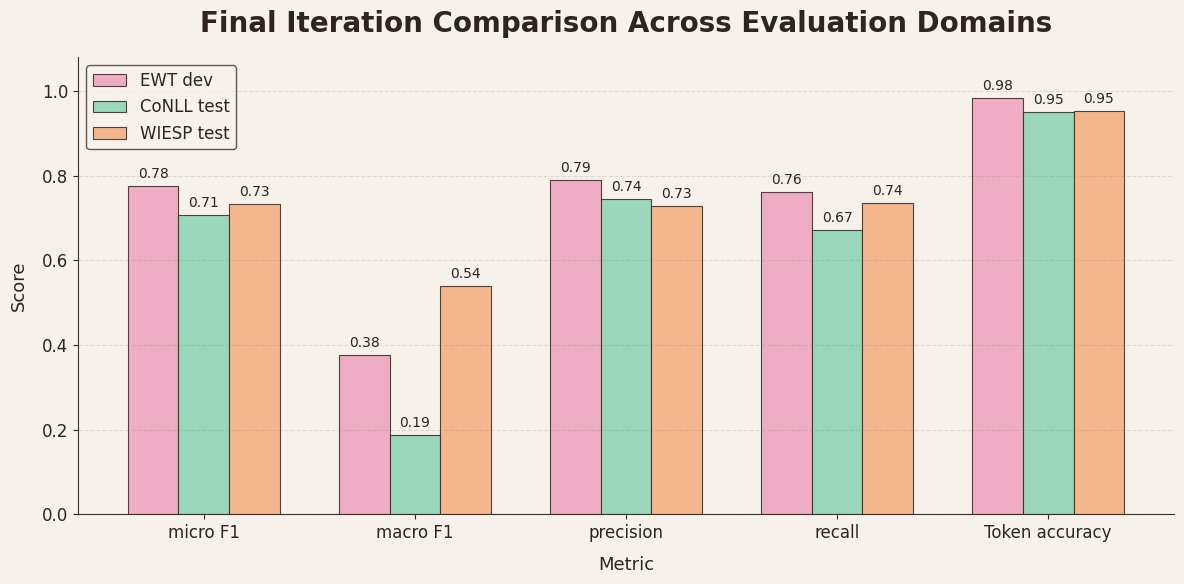

In [ ]:
metrics_to_compare = ["entity_f1_micro", "entity_f1_macro", "entity_precision", "entity_recall", "token_acc"]
final_pivot = final_df.set_index("eval_set")[metrics_to_compare].loc[["ewt_dev", "conll_test", "astro_test"]]

x = np.arange(len(metrics_to_compare))
width = 0.24

fig, ax = plt.subplots(figsize=(12, 6))

for i, eval_set in enumerate(final_pivot.index):
    values = final_pivot.loc[eval_set].values.astype(float)
    bars = ax.bar(
        x + (i - 1) * width,
        values,
        width=width,
        alpha=0.9,
        color=DOMAIN_COLORS[eval_set],
        edgecolor=EDGE,
        linewidth=0.8,
        label=DOMAIN_LABELS[eval_set]
    )
    add_bar_labels(ax, bars, fmt="{:.2f}", y_offset=0.012)

ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABELS[m].replace("Entity ", "") for m in metrics_to_compare])

finish_plot(
    "Final Iteration Comparison Across Evaluation Domains",
    xlabel="Metric",
    ylabel="Score"
)
plt.ylim(0, 1.08)
plt.show()

## 8. Gain over iteration 0

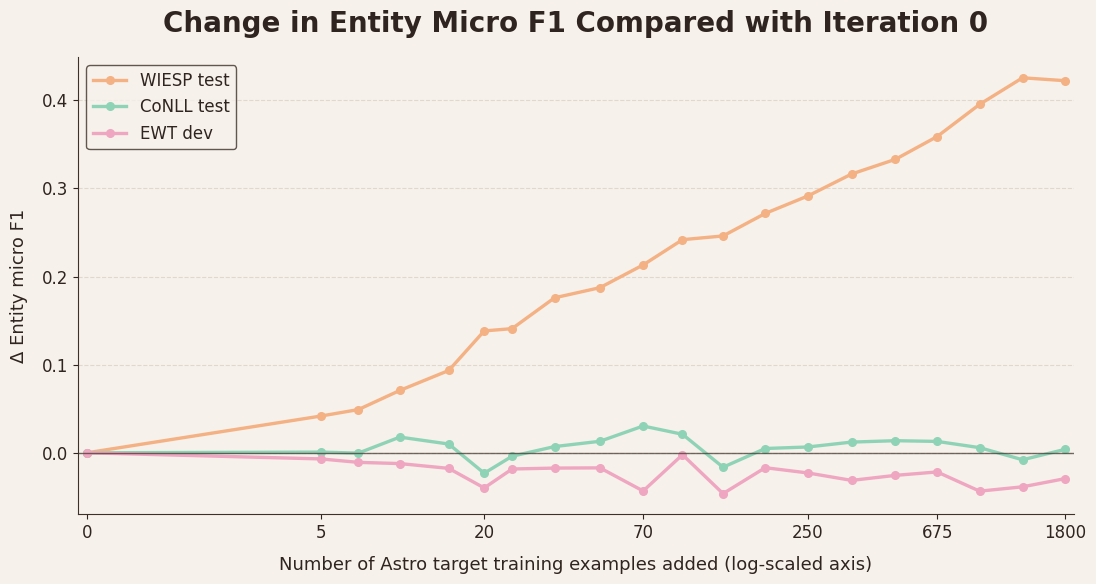

In [ ]:
plt.figure(figsize=(11, 6))

for eval_set, sub in analysis_df.groupby("eval_set"):
    sub = sub.sort_values("n_target_examples")
    plt.plot(
        target_x(sub["n_target_examples_display"]),
        sub["delta_f1_vs_iter0"],
        marker="o",
        linewidth=2.4,
        markersize=5.5,
        color=DOMAIN_COLORS.get(eval_set, "gray"),
        label=DOMAIN_LABELS.get(eval_set, eval_set)
    )

plt.axhline(0, color=EDGE, linewidth=1.0, alpha=0.7)

finish_plot(
    "Change in Entity Micro F1 Compared with Iteration 0",
    xlabel="Astro target training examples added (×30 sentence-equivalent, log-scaled axis)",
    ylabel="Δ Entity micro F1"
)
apply_target_xaxis()
plt.show()

## 9. Per-entity WIESP performance

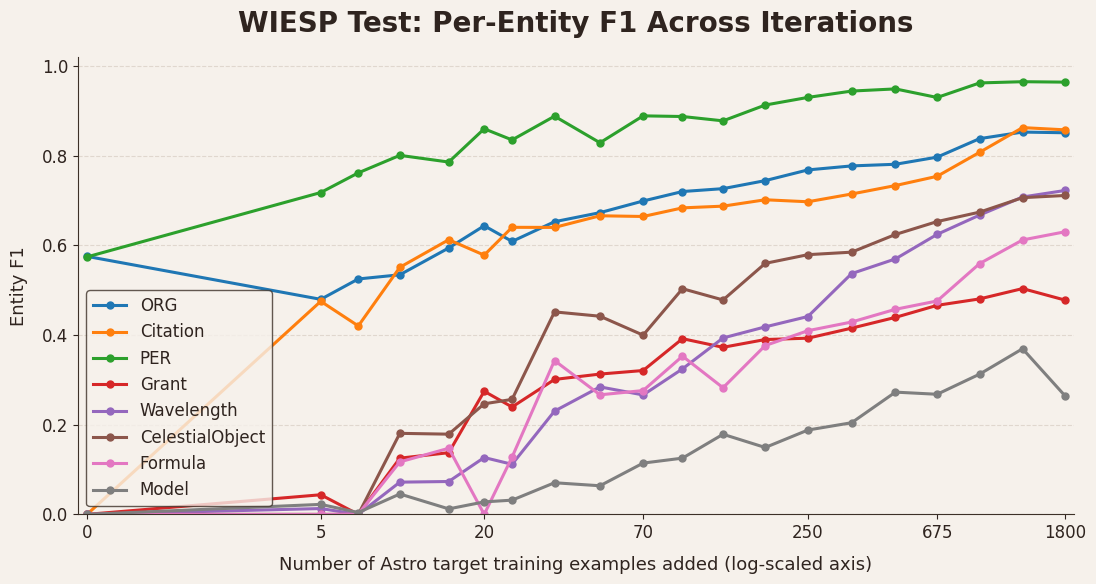

,entity,f1,support
19,ORG,0.851031,10436.0
4,Citation,0.857570,6042.0
22,PER,0.963964,5940.0
13,Grant,0.477929,5038.0
30,Wavelength,0.722348,3151.0
1,CelestialObject,0.711168,2419.0
12,Formula,0.630231,2401.0
18,Model,0.264483,2366.0
16,LOC,0.869210,2097.0
27,Telescope,0.669703,1881.0


In [ ]:
final_astro = astro_df[astro_df["iteration"] == final_iter].iloc[0]

entity_rows = []
for f1_col in f1_type_cols:
    entity = f1_col.replace("f1_", "")
    support_col = f"support_{entity}"

    if support_col in final_astro.index:
        f1 = final_astro[f1_col]
        support = final_astro[support_col]

        if pd.notna(f1) and pd.notna(support) and support > 0:
            entity_rows.append({
                "entity": entity,
                "f1": f1,
                "support": support
            })

entity_summary = pd.DataFrame(entity_rows).sort_values("support", ascending=False)
top_entities = entity_summary.head(8)["entity"].tolist()

plt.figure(figsize=(11, 6))

for entity in top_entities:
    col = f"f1_{entity}"
    plt.plot(
        target_x(astro_df["n_target_examples_display"]),
        astro_df[col],
        marker="o",
        linewidth=2.2,
        markersize=5,
        label=entity
    )

finish_plot(
    "WIESP Test: Per-Entity F1 Across Iterations",
    xlabel="Astro target training examples added (×30 sentence-equivalent, log-scaled axis)",
    ylabel="Entity F1"
)
plt.ylim(0, 1.02)
apply_target_xaxis()
plt.show()

entity_summary.head(15)

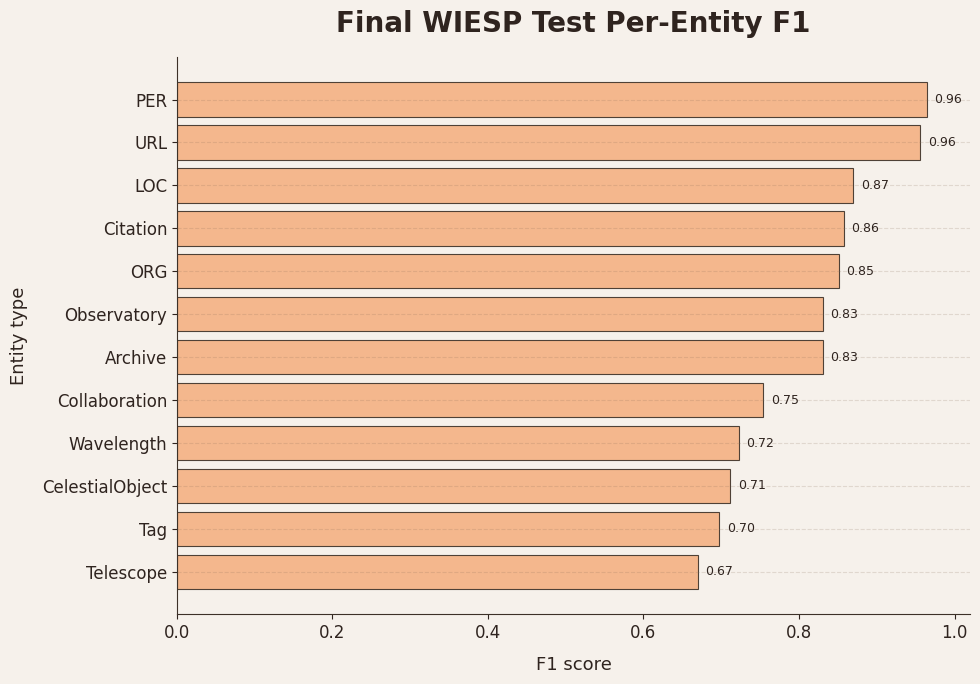

In [ ]:
plot_df = entity_summary.sort_values("f1", ascending=False).head(12).sort_values("f1")

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    plot_df["entity"],
    plot_df["f1"],
    color="#F4B183",
    alpha=0.9,
    edgecolor=EDGE,
    linewidth=0.8
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9,
        color=TEXT
    )

finish_plot(
    "Final WIESP Test Per-Entity F1",
    xlabel="F1 score",
    ylabel="Entity type",
    legend=False
)
plt.xlim(0, 1.02)
plt.show()

## 10. Precision-recall balance on WIESP

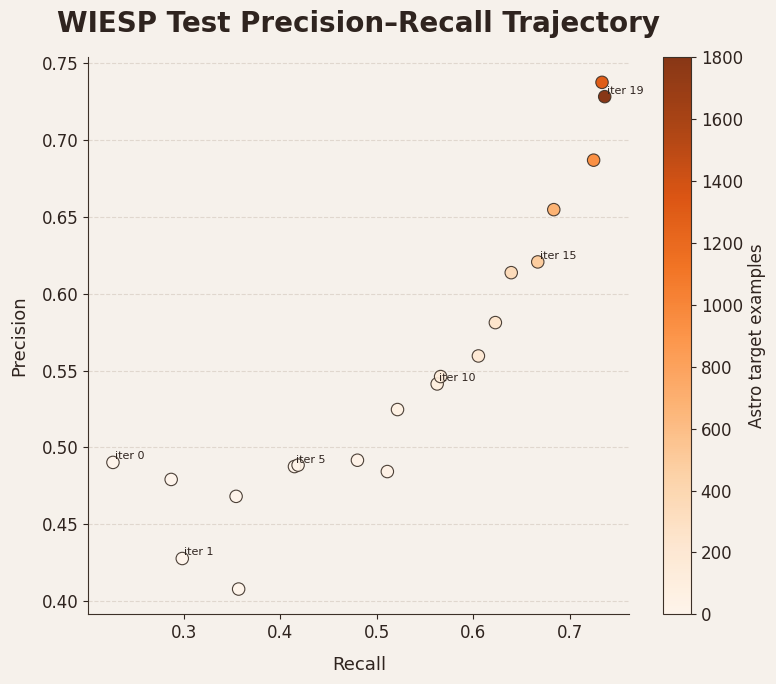

In [ ]:
plt.figure(figsize=(8, 7))

sc = plt.scatter(
    astro_df["entity_recall"],
    astro_df["entity_precision"],
    s=80,
    c=astro_df["n_target_examples_display"],
    cmap="Oranges",
    edgecolor=EDGE,
    linewidth=0.8,
    alpha=0.92
)

for _, row in astro_df.iterrows():
    if row["iteration"] in [0, 1, 5, 10, 15, 19]:
        plt.text(
            row["entity_recall"] + 0.002,
            row["entity_precision"] + 0.002,
            f"iter {int(row['iteration'])}",
            fontsize=8,
            color=TEXT
        )

cbar = plt.colorbar(sc)
cbar.set_label("Astro target examples (×30 sentence-equivalent)", color=TEXT)
cbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cbar.ax.get_yticklabels(), color=TEXT)

finish_plot(
    "WIESP Test Precision–Recall Trajectory",
    xlabel="Recall",
    ylabel="Precision",
    legend=False
)
plt.show()

## 11. Confusion matrices

The CoNLL notebook could load per-iteration confusion matrix CSV files from the full run folders.

For Astro, only `summary.csv` is currently available in `runs/iter_astro/`, so confusion matrices cannot be plotted yet. This section should be completed later if the per-iteration folders are recovered, for example:

```text
runs/iter_astro/seeds/seed_42/iter_019/confusion_matrix_astro_test.csv
```


In [ ]:
print("Confusion matrices are not available from summary.csv alone.")
print("This section requires per-iteration confusion_matrix_*.csv files.")

Confusion matrices are not available from summary.csv alone.
This section requires per-iteration confusion_matrix_*.csv files.


## 12. Training dynamics from `train_log.jsonl`

The CoNLL notebook used `train_log.jsonl` files to plot epoch-level train loss, dev loss, and dev F1.

For Astro, those per-iteration training logs were not recovered, so this section cannot be plotted from `summary.csv` alone.


In [ ]:
print("Training dynamics are not available from summary.csv alone.")
print("This section requires per-iteration train_log.jsonl files.")

Training dynamics are not available from summary.csv alone.
This section requires per-iteration train_log.jsonl files.


## 13. Efficiency and resource analysis

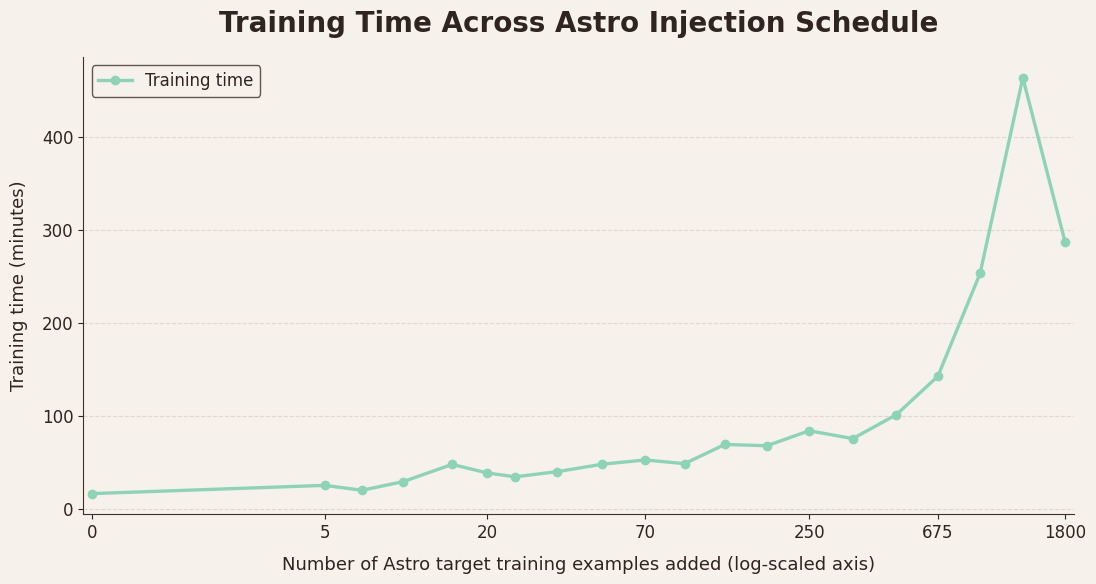

In [ ]:
resource = summary[[
    "seed", "iteration", "n_target_examples", "n_target_examples_display", "train_time_sec", "best_epoch", "peak_gpu_mem_mb"
]].drop_duplicates()

resource_avg = resource.groupby(["iteration", "n_target_examples", "n_target_examples_display"], as_index=False).agg(
    train_time_sec_mean=("train_time_sec", "mean"),
    best_epoch_mean=("best_epoch", "mean"),
    peak_gpu_mem_mb_mean=("peak_gpu_mem_mb", "mean"),
)

plt.figure(figsize=(11, 6))

plt.plot(
    target_x(resource_avg["n_target_examples_display"]),
    resource_avg["train_time_sec_mean"] / 60,
    marker="o",
    linewidth=2.4,
    color="#8FD3B6",
    label="Training time"
)

finish_plot(
    "Training Time Across Astro Injection Schedule",
    xlabel="Astro target training examples added (×30 sentence-equivalent, log-scaled axis)",
    ylabel="Training time (minutes)"
)
apply_target_xaxis()
plt.show()

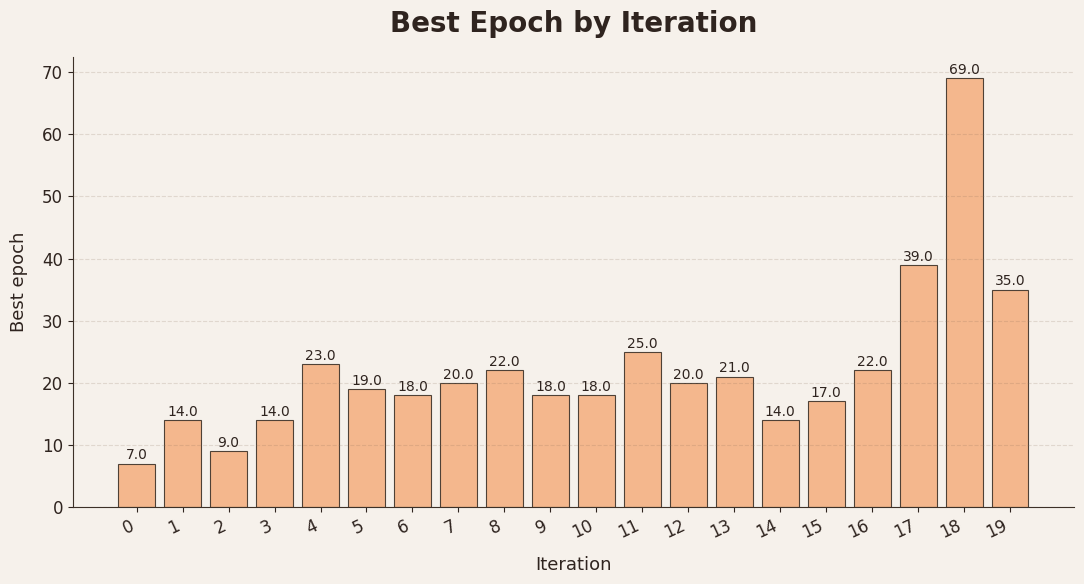

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    resource_avg["iteration"].astype(str),
    resource_avg["best_epoch_mean"],
    color="#F4B183",
    alpha=0.9,
    edgecolor=EDGE,
    linewidth=0.8
)

add_bar_labels(ax, bars, fmt="{:.1f}", y_offset=0.2)

finish_plot(
    "Best Epoch by Iteration",
    xlabel="Iteration",
    ylabel="Best epoch",
    legend=False,
    rotate_x=True
)
plt.show()

## 14. Automatic result tables for the report

In [ ]:
final_table = final_df[[
    "eval_set", "n_target_examples", "entity_f1_micro", "entity_f1_macro",
    "entity_precision", "entity_recall", "token_acc", "token_f1", "eval_loss"
]].copy()

final_table["eval_set"] = final_table["eval_set"].map(DOMAIN_LABELS)

final_table.round(4)

,eval_set,n_target_examples,entity_f1_micro,entity_f1_macro,entity_precision,entity_recall,token_acc,token_f1,eval_loss
57,WIESP test,1800,0.7321,0.5392,0.7281,0.7362,0.9522,0.6434,0.4441
58,CoNLL test,1800,0.7061,0.1881,0.7446,0.6715,0.9510,0.2678,0.4540
59,EWT dev,1800,0.7756,0.3763,0.7897,0.7619,0.9820,0.4888,0.1311


In [ ]:
astro_progression = astro_df[[
    "iteration", "n_target_examples", "target_fraction", "entity_f1_micro", "entity_f1_macro",
    "entity_precision", "entity_recall", "token_acc", "token_f1", "eval_loss"
]].round(4)

astro_progression

,iteration,n_target_examples,target_fraction,entity_f1_micro,entity_f1_macro,entity_precision,entity_recall,token_acc,token_f1,eval_loss
0,0,0,0.0000,0.3099,0.0466,0.4903,0.2266,0.8420,0.0873,1.9960
3,1,5,0.0004,0.3516,0.0660,0.4278,0.2984,0.8730,0.1247,1.3613
6,2,7,0.0006,0.3589,0.0642,0.4792,0.2869,0.8715,0.1186,1.3499
9,3,10,0.0008,0.3807,0.0978,0.4079,0.3568,0.8807,0.1679,1.1221
12,4,15,0.0012,0.4033,0.1107,0.4682,0.3542,0.8864,0.2005,1.2781
15,5,20,0.0016,0.4482,0.1396,0.4876,0.4147,0.8946,0.2445,0.8008
18,6,25,0.0020,0.4508,0.1414,0.4885,0.4184,0.8978,0.2423,0.9299
21,7,35,0.0028,0.4858,0.2091,0.4917,0.4799,0.9061,0.3249,0.7673
24,8,50,0.0040,0.4973,0.2340,0.4843,0.5109,0.9105,0.3529,0.7269
27,9,70,0.0055,0.5231,0.2564,0.5246,0.5215,0.9143,0.3736,0.7400


## Short report interpretation notes

Use careful wording for this notebook:

- These are **single-seed Astro results**, not seed-averaged final results.
- The main learning-curve and metric trends are still valid for describing the recovered run.
- Do not claim robustness across seeds yet.
- Confusion-matrix and training-dynamics analysis require the missing per-iteration folders.
- Once the other seeds are completed, rerun this notebook after replacing `summary.csv` with the full Astro summary.
